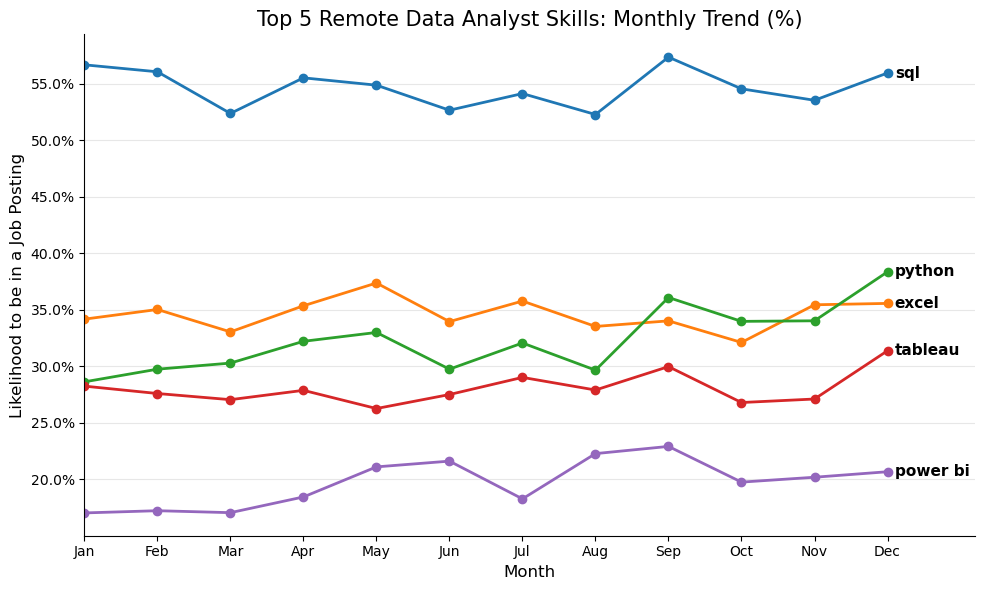

In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# loading Dataset
df = pd.read_csv("data_jobs.csv")
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Filter and Sort Data
df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_work_from_home'] == True)].copy()
df_DA['job_posted_month'] = df_DA['job_posted_date'].dt.strftime('%b')
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_DA['job_posted_month'] = pd.Categorical(df_DA['job_posted_month'], categories=months_order, ordered=True)
DA_totals_by_month = df_DA.groupby('job_posted_month').size()
df_DA = df_DA.dropna(subset=['job_skills'])
df_DA['job_skills'] = df_DA['job_skills'].str.replace(r"[\[\]']", "", regex=True).str.split(", ")
df_DA_exploded = df_DA.explode('job_skills')
df_DA_pivot = df_DA_exploded.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_pivot_pct = df_DA_pivot.div(DA_totals_by_month, axis=0) * 100

# Top 5 Skills overall
top_5_skills = df_DA_pivot.sum().sort_values(ascending=False).head(5).index
df_plot = df_DA_pivot_pct[top_5_skills]

# Plot Trend
ax = df_plot.plot(kind='line', figsize=(10, 6), marker='o', linewidth=2)
plt.title('Top 5 Remote Data Analyst Skills: Monthly Trend (%)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Likelihood to be in a Job Posting', fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter())

plt.xticks(ticks=range(len(months_order)), labels=months_order)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.get_legend().remove()

for skill in df_plot.columns:
    final_value = df_plot[skill].iloc[-1]
    plt.text(11.1, final_value, skill, fontsize=11, fontweight='bold', va='center')

plt.xlim(0, 12.2)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()